Nombres y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3


# Grafos en la vida real

En esta práctica vamos a, usando los conocimientos sobre grafos aprendidos en las prácticas anteriores, crear grafos y explorlos usando datos de la vida real. Para la obtención de estos datos, vamos a usar la librería ``PytorchGeometric``. Esta librería está diseñada para desarrollar y entrenar redes neuronales. Esta librería maneja datos estructurados en forma de grafos, es por eso que esta librería es perfecta para esta práctica.

Vamos ahora a importar todas las librerías que vamos a usar en esta práctica:

In [41]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown
from gensim.models import Word2Vec
import numpy as np
from sklearn.decomposition import PCA

## 1. Node2vec

`Node2vec` es básicamente un algoritmo de aprendizaje automático de representaciones numéricas (embeddings) para cada nodo. La clave está en que, si dos nodos son cercanos sus representaciones también serán cercanas. Para lograr est objetivo, `node2vec` **no** realiza un camino aleatorio (**random walk**), si no que realiza un camino sesgado que controla si el recorrido se mantiene cerca o explora más lejos

### 1.1 Embeddings y word2vec

Una incrustación (o embedding) de un nodo es una representación numérica que resume su papel dentro del grafo. Estas incrustaciones tienes distinitas utilidades:
- Agrupar nodos por similitud
- Clasificar nodos
- Predicción de enlaces (predecir si dos nodos deberían estar concetados)

Las características de estas incrustaciones tienen bastante en común con `Word2vec` en textos, donde las palabras que suelen aparecer juntas tienen representaciones numéricas cercanas. Además, `node2vec` aplica esa misma lógica en los grafos pero usando _random walks_ y en lugar de frases. 

Los embeddings son muy útiles puesto que nos permiten trabajar con información compleja (como grafos que tengan nodos con muchas conexiones) de forma compacta y fácil, quedándonos solo con lo importante

### 1.2 El algoritmo Node2vec

Este algoritmo es una técnica de aprendizaje de representaciones de diseñada exclusivamente para grafos. El objetivo de este algoritmo es aprender embeddings de los nodos, es decir, convertir cada nodo en una lista de vectores (de ahí el nombre: _node_ -> _vec_) que resuma el papel de ese nodo dentro del grafo. La propiedad fundamental es: si dos nodos están cerca en el grafo, sus respresnetaciones numéricas también lo están. Esta propiedad permite al algoritmo capturar relaciones complejas que no siempre son evidentes.

Para cumplir dichos objetivos, `node2vec` funciona en dos pasos:

**Primer paso**
- Generar caminos aleatorios (_random walk_). Sin embargo, este algoritmo no genera caminos de forma aleatoria al 100%, si no que genera los caminos según dos parámetros: \
   -> p: Controla la probabilidad de volver hacia atrás (regresión al nodo anterior)\
   ->  q: Controla si el camino tiende a explorar nodos más lejanos 

Gracias a estos parámetros, el algoritmo puede implementar estrategias de búsqueda como DFS o BFS. Este primer paso se repite muchas veces desde distintos nodos iniciales, generando así un conjunto de secuencias de nodos

**Segundo paso**
- Aprender los embeddings a partir de los caminos aleatorios generados en el primer paso. Aquí es donde este algoritmo y `word2vec` se relacionan: `node2vec` toma cada camino y lo mira como si fuera una frase (los nodos son palabras y el camino es la oración). Luego, utiliza `Skip-Gram` (variante de `word2vec`). Este algoritmo funciona de la siguiente manera: por cada nodo del camino, se coloca como "nodo central" y se predice que nodos aparecen antes y después dentro de una ventana de tamaño fijo. Como los caminos ya contienen la estructura del grafo, el resultado final es que las instructaciones aprendidas codifican tanto las relaciones locales como las gobales del grafo. De esta forma, cada nodo queda representado por un vector numérico que resume su papel dentro del grafo (posición, función...)

#### 1.2.1 Node2vec (código)

Vamos ahora a explicar los distintos bloques que contiene el `node2vec` explicando cada uno con el objetivo de que se entienda mejor

In [4]:
# Función para realizar una caminata aleatoria en el grafo
def node2vec_walk(G, start_node, walk_length):
    walk = [start_node]
    while len(walk) < walk_length:
        cur_node = walk[-1]
        neighbors = list(G.neighbors(cur_node))
        if len(neighbors) > 0:
            walk.append(np.random.choice(neighbors))  # Selecciona un vecino al azar
        else:
            break
    return walk

##### **BLOQUE 1** 
---
Función que realiza un camino aleatorio por el grafo. Recibe como argumentos:
- **G**: Grafo que se va a recorrer
- **start_choice**: Nodo desde donde se va a empezar a generar el camino
- **walk_length**: Longitud deseada del camino a generar

Devuelve:
- walk: camino generado
---
**Funcionamiento de la función**
- **walk**: Inicializa el camino desde el nodo de inicio. De momento, el camino es una lista que solo contiene el nodo inicial
- _while_: Bucle que se ejecuta mientras que la longitud del camino sea menor que la deseada
- **cur_node**: Accede al último elemento ([-1]) del camino que se convierte en el nodo actual desde el cuál se va a dar el siguiente paso
- **neighbors**: Obtenemos todos los vecinos del nodo actual
- _if_: Comprueba si el nodo actual tiene al menos un vecino. Si el nodo no tiene vecinos (hoja) salimos del bucle
- **walk.append**: Elegimos un vecino al azar y lo añadimos al camino 

In [5]:
# Función para generar múltiples caminatas aleatorias desde cada nodo del grafo
def generate_walks(G, num_walks, walk_length):
    walks = []
    nodes = list(G.nodes())
    for _ in range(num_walks):
        np.random.shuffle(nodes)  # Mezcla los nodos para añadir aleatoriedad
        for node in nodes:
            walks.append(node2vec_walk(G, node, walk_length))  # Genera una caminata aleatoria desde el nodo
    return walks

##### **BLOQUE 2** 
---
Función que genera varios caminos. Recibe como argumentos:
- **G**: Grafo que se va a recorrer
- **num_walks**: Número de caminos que se van a generar
- **walk_length**: Longitud deseada de los caminos a generar

Devuelve:
- walks: caminos generados
---
**Funcionamiento de la función**
- **walk**: Lista donde se van a guardar todos los caminos que se vayan a generar
- **nodes**: Obtiene todos los nodos del grafo y los guarda en una lista (nodes)
- _for_: Bucle que se ejecuta tantas veces como el número de caminos que le hayamos especificado
- **np.random.shuffle**: Mezcla (shuffle) el orden de los nodos al azar. Este paso es importante ya que nos aseguramos de que los caminos aleatorios no empiecen siempre en el mismo orden (añadimos variedad)
- _for_: Recorre cada nodo del grafo 
- **node2vec_walk**: Corazón de la función. Para cada nodo (aleatorio ya que han sido mezclados) llama a la función `node2vec_walk()` (bloque 1) y genera un camino partienod de este y guarda el camino en la lista `walks` 

In [6]:
# Función principal de Node2Vec
def node2vec(G, dimensions, num_walks, walk_length):
    walks = generate_walks(G, num_walks, walk_length)  # Genera todas las caminatas aleatorias
    walks = [list(map(str, walk)) for walk in walks]  # Convierte los nodos a cadenas para gensim
    # walks: Lista de caminatas aleatorias
    # vector_size=dimensions: Tamaño del vector de embeddings
    # window=5: Tamaño de la ventana de contexto, en nodos seria 5 nodos a la izquierda y 5 nodos a la derecha
    # workers=2: Número de hilos para entrenar el modelo
    model = Word2Vec(walks, vector_size=dimensions, window=5, workers=2)  # Entrena el modelo Word2Vec con las caminatas aleatorias
    return model

##### **BLOQUE 3** 
---
Función principal. Aquí es donde entrenamos el modelo `word2vec` pasándole caminos aleatorios como frases. Recibe como argumentos:
- **G**: Grafo que se va a recorrer
- **dimensions**: Dimensión de los embeddings. Es un número entero que dicta cuántos números va a tener el vector (embedding) que represeneta cada nodo (cuanto más grande, más información tendrán los nodos)
- **num_walks**: Número de caminos que se van a generar partiendo desde cada nodo del grafo
- **walk_length**: Longitud deseada de los caminos a generar

Devuelve:
- walks: caminos generados
---
**Funcionamiento de la función**
- **walk**: Llamamos a la función **generate_walks** para generar caminos aleatorios por el grafo. Luego, se convierte cada nodo de cada camino a un string. Hacemos esto porque `Word2vec` espera que los argumentos sean de tipo "str". Guardamos todo en una lista
- **model**: Crea y entrena el modelo `word2vec` usando los caminos generados como si fueran frases
- **return**: Devuelve ya entrenado. Una vez tenemos el modelo entrenado, podemos obtener los embeddings de cada nodo usando: `model.wv['nodo']`

#### 1.2.1 Node2vec (ejecución)

Ahora que ya hemos implementado y explicado el algoritmo, vamos a ejecutarlo sobre un grafo sintético SBM:

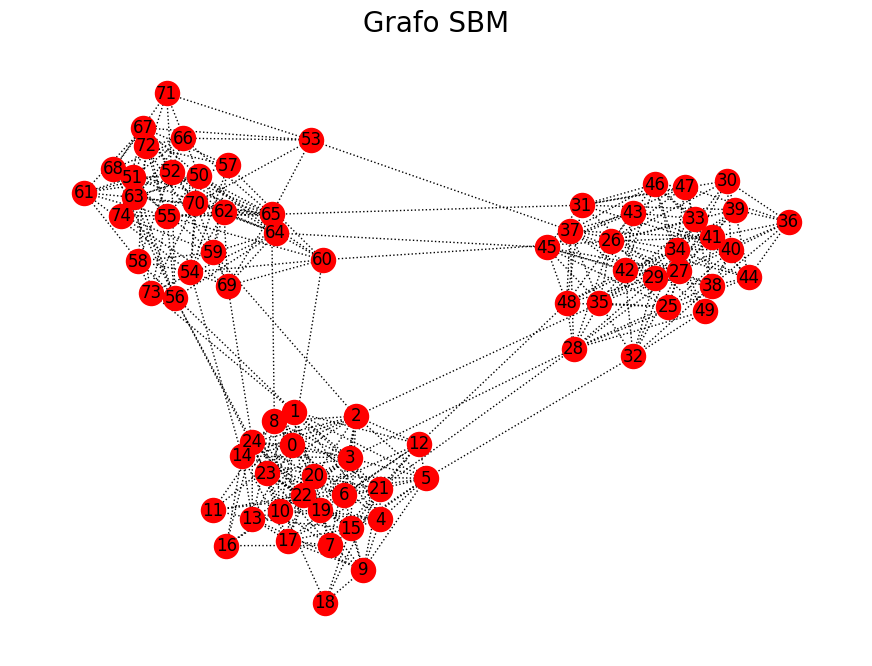

### **Información del grafo**
---

Embedding del nodo **5**:

[-0.8226174  -0.8339627  -0.78305656 -1.2767404   0.14644846 -0.49267852
  0.8521006   0.66790205 -0.87812114 -0.7881876   0.18509565  0.7407289
  0.33222136 -0.23238319 -0.19062172 -0.7218965  -0.24841855  0.10434193
 -1.0564533  -0.39015013]


---

### **Información de los embeddings del grafo**

Embeddings shape: (75, 20)
Embeddings mean: 0.033312276005744934
Embeddings max: 2.596097707748413
Embeddings min: -1.8702274560928345


In [ ]:
# Creamos el grafo con modelo de bloques estocásticos (comunidades)
g = nx.stochastic_block_model([25, 25, 25], [ 
                                            [0.4, 0.01, 0.01],
                                            [0.01, 0.4, 0.01],
                                            [0.01, 0.01, 0.4]], seed=42)
#-------------------------------------------------------------------#

# Ahora que tenemos el grafo creado, vamos primeramente a visualizarlo:
plt.figure(figsize=(11, 8))
plt.title("Grafo SBM", fontsize = 20)
pos = nx.spring_layout(g, seed=99)
nx.draw(g, pos, with_labels=True, node_color='red', edge_color='black', style=":")
plt.axis('off')
plt.show()

#---------------------------------------------------------------------#

# Pasamos ahora con node2vec. La idea es entrenar el modelo word2vec sobre el grafo anteriormente creado
model = node2vec(g, dimensions=20, num_walks=15, walk_length=90)  # Entrena el modelo Node2Vec 
                                                                  # Embeddings: Dimensión de 20
                                                                  # 15 caminos aleatorios a generar con longitud 90 cada uno

#⨪--------------------------------------------------------------------#

# Información a obtener

# Obtiene el embedding de un nodo específico (por ejemplo, nodo 0)
node_id = 5
embedding = model.wv[str(node_id)]
display(Markdown(f'### **Información del grafo**\n---'))
display(Markdown(f'Embedding del nodo **{node_id}**:')) # Embedding del nodo 5
print(embedding)

display(Markdown(f'---'))
display(Markdown(f'### **Información de los embeddings del grafo**'))

# Obtienemos los embeddings de todos los nodos
embeddings = np.array([model.wv[str(node)] for node in g.nodes()])
print(f"Embeddings shape: {embeddings.shape}") # Embeddings shape
print(f"Embeddings mean: {embeddings.mean()}") # Embeddings mean
print(f"Embeddings max: {embeddings.max()}") # Embeddings max
print(f"Embeddings min: {embeddings.min()}") # Embeddings min

#### 1.4 Visualización embeddings

Una vez que hemos aprendido las caracterísitcas de los embeddins, nos planteamos el visualizarlos. El problema está en que no podemos visualizar directamente vectores de altas dimensiones. Para solucionar esto, existen técnicas de reducción de dimensiones como **PCA** o **t-SNE**. Estos métodos se basan en reducir dimensiones de vectores pero manteniendo las distancias y similitudes entre nodos. Es decir, si dos nodos eran parecidos en el espacio original, después de aplicar reducción esta similitud se debe de seguir viendo. 

Algunas librerías como `sklearn` tienen implementadas las técnicas mencionadas, luego vamos a poner un ejemplo aplicando reducción y luego mostrando los embeddings por terminal:

### **PCA**
---

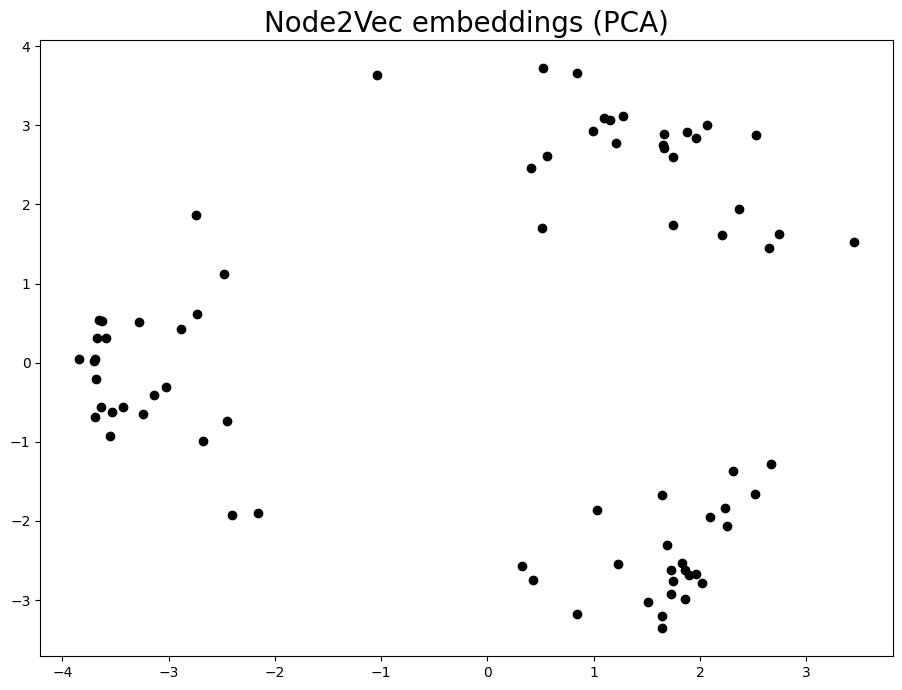

In [47]:
from sklearn.decomposition import PCA

# Vamos a aplicar la técnica PCA

pca = PCA(n_components=2)                          # Creamos la instancia PCA que reduce los embeddings a 2 componentes (n_components = 2)
                                                   # Quire decir que pasamos de las 20 dimensiones originales a solamente 2 (las más relevantes)   
embeddings_pca = pca.fit_transform(embeddings)     # Aplicamos la reducción a los embeddings usando fit_transform() que hace:
                                                   #    # -> fit: calcula ejes principales
                                                   #    # -> transform: proyecta embeddins sobre los ejes calculados

#--------------------------------------------------#

# Una vez realizada la reducción, ya somos capaces de visualizar los embeddings

plt.figure(figsize=(11, 8))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], color='black')    # embeddings_pca[:, 0] -> Columna 0 (ejex) de todas las filas
                                                                          # embeddings_pca[:, 1] -> Columna 1 (ejey) de todas las filas
plt.title("Node2Vec embeddings (PCA)", fontsize = 20)
plt.show()

### **PCA (3D)** 
---

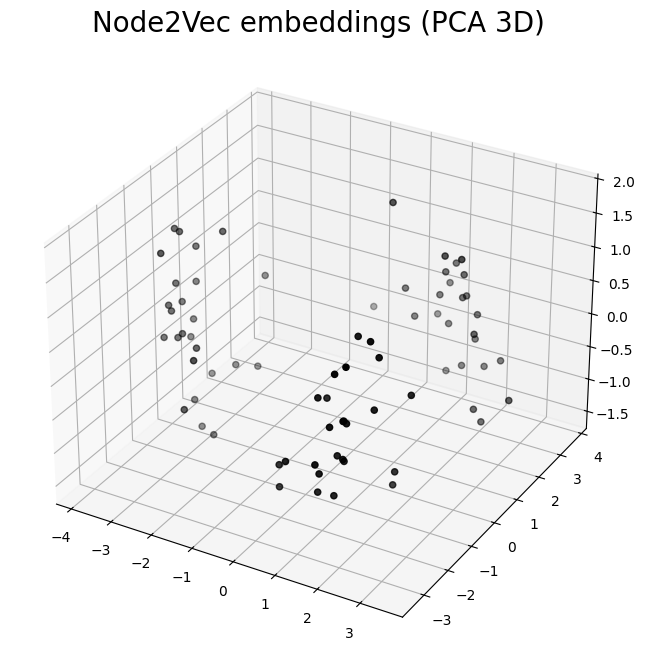

In [55]:
# Vamos a aplicar la técnica PCA pero ahora en 3 dimensiones

pca_3d = PCA(n_components=3)                          # Creamos la instancia PCA que reduce los embeddings a 3 componentes (n_components = 3)
                                                      # Quiere decir que pasamos de las 20 dimensiones originales a solamente 3 (las más relevantes)
embeddings_pca_3d = pca_3d.fit_transform(embeddings)  # Aplicamos la reducción a los embeddings usando fit_transform() que hace:
                                                      #    # -> fit: calcula ejes principales
                                                      #    # -> transform: proyecta embeddings sobre los ejes calculados

#--------------------------------------------------#

# Una vez realizada la reducción, ya somos capaces de visualizar los embeddings en 3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')    # Creamos un subplot con proyección 3D

ax.scatter(embeddings_pca_3d[:, 0],           # embeddings_pca_3d[:, 0] -> Columna 0 (eje X) de todas las filas
           embeddings_pca_3d[:, 1],           # embeddings_pca_3d[:, 1] -> Columna 1 (eje Y) de todas las filas
           embeddings_pca_3d[:, 2],           # embeddings_pca_3d[:, 2] -> Columna 2 (eje Z) de todas las filas
           color='black')                     # alpha=0.7 da un poco de transparencia para mejor visualización

ax.set_title("Node2Vec embeddings (PCA 3D)", fontsize=20)

plt.show()

### **t-SNE**
---

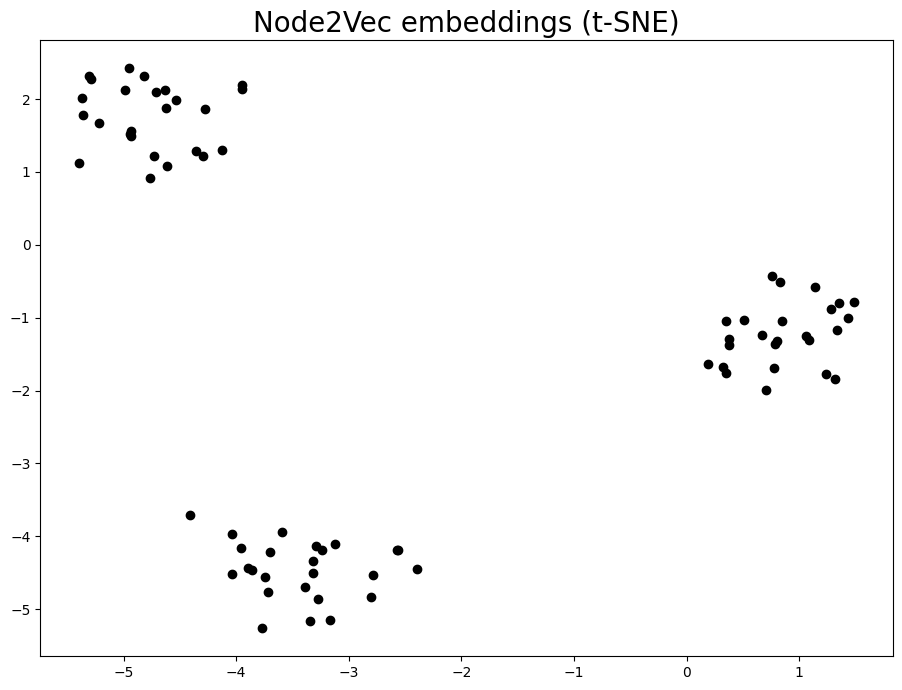

In [138]:
from sklearn.manifold import TSNE

# Vamos a aplicar la técnica t-SNE (t-Distributed Stochastic Neighbor Embedding)

t_sne = TSNE(n_components=2,                           # Reducimos a 2 dimensiones para poder visualizar
            perplexity=30,                            # Perplejidad: balance entre vecinos locales y globales (típico 5-50)
            random_state=42)                          # Semilla fija para que los resultados sean reproducibles

#--------------------------------------------------#

embeddings_tsne = t_sne.fit_transform(embeddings)      # Aplicamos t-SNE a los embeddings
                                                      # fit_transform() hace:
                                                      #    # -> Calcula las probabilidades de similitud entre pares de puntos
                                                      #    # -> Minimiza la divergencia de Kullback-Leibler entre distribuciones
                                                      #    # -> Proyecta los datos en un espacio de baja dimensión

#--------------------------------------------------#

# Una vez realizada la reducción, ya somos capaces de visualizar los embeddings

plt.figure(figsize=(11, 8))
plt.scatter(embeddings_tsne[:, 0],        # embeddings_tsne[:, 0] -> Columna 0 (eje X) de todas las filas
            embeddings_tsne[:, 1],        # embeddings_tsne[:, 1] -> Columna 1 (eje Y) de todas las filas
            color='black')       

plt.title("Node2Vec embeddings (t-SNE)", fontsize=20)
plt.show()


_documentación usada para implementar t-SNE_: \
https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

## 2. Ejercicios

### Ejercicio 2

El objetivo de este ejercicio es aplicar el algoritmo `node2vec` estudiado en esta sección a los nodos sintéticos generados en la práctica anterior. Después, visualizamos los embeddings aplicando primero una reducción de dimensiones con PCA o t-SNE. Debido a estos objetivos, vamos a crear una serie de funciones para poder aplicarlas a todos los grafos a estudiar:

In [ ]:
# FUNCIONES AUXILIARES
#⨪--------------------#

# FUNCIÓN PCA
def pca(embeddings):
    """
    Función que reduce las dimensiones de embeddings (por defecto a 2) aplicando la técnica de reducción PCA

    Args
    -----
        - embeddings: Vectores de alta dimensión que se quieren reducir

    Returns
    -------
        - embeddings_pca: Embeddings reducidos a 2 dimensiones

    """
    pca = PCA(n_components=2)                                             
    embeddings_pca = pca.fit_transform(embeddings)   

    return embeddings_pca, "PCA"

# FUNCIÓN T-SNE
def t_sne(embeddings):
    """
    Función que reduce las dimensiones de embeddings (por defecto a 2) aplicando la técnica de reducción t-SNE

    Args
    -----
        - embeddings: Vectores de alta dimensión que se quieren reducir

    Returns
    -------
        - embeddings_sne: Embeddings reducidos a 2 dimensiones

    """
    tsne = TSNE(n_components=2, perplexity=25, random_state=42)                        
    embeddings_tsne = tsne.fit_transform(embeddings)    

    return embeddings_tsne, "t-SNE"

# ALGORITMO NODE2VEC -> Implementado anteriormente (node2vec())

# FUNCIÓN NODE2VEC + EMBEDDINGS
def n2v(g):
    """
    Función que aplica el modelo node2vec a un grafo dado, obtiene los embeddings del grafo 
    y luego aplica a estos una técina de reducción de dimensiones (PCA o t-SNE -> se elige
    aleaotoriamente)

    Args
    -----
        - g: Grafo al que se aplica node2vec
    
    Returns
    -------
        - embeddings_2d: Embdeddins con las dimensiones reducidas (a 2D por defecto)
        - name: Nombre de la técnica de reducción que se haya usado
        - embeddings: Embeddings originales (sin reducción)
    
    """
    model = node2vec(g, dimensions=20, num_walks=15, walk_length=90)
    embeddings = np.array([model.wv[str(node)] for node in g.nodes()]) # embeddings 

    # APLICAMOS REDUCCIÓN A LOS EMBEDDINGS OBTENIDOS
    method = np.random.choice([pca, t_sne])
    embeddings_2d, name = method(embeddings)

    return embeddings_2d, name, embeddings

def properties(embeddings) -> None:
    """
    Función que muestra por pantalla propiedades de embeddings
    
    """

    display(Markdown(f'### **Información de los embeddings del grafo**'))
    print(f"Embeddings shape: {embeddings.shape}") 
    print(f"Embeddings mean: {embeddings.mean()}") 
    print(f"Embeddings max: {embeddings.max()}") 
    print(f"Embeddings min: {embeddings.min()}") 
    

# FUNCIÓN DE VISUALIZACIÓN
def visualization(g) -> None:
    """
    Esta función muestra de forma visual un grafo y sus embeddings después de aplicar node2vec. El objetivo es mostrar en una figura 
    dos visualizaciones: en la primera mostramos el grafo original y en la segunda los embeddings del mismo. Además, debajo de imprimen
    por pantalla los datos obtenidos despues de aplicar node2vec al grafo. Para mostrar las visualizaciones, se utiliza o PCA o t-SNE, cuya
    elección se aleatoria (en las dos reducimos a 2 dimensiones)

    Args
    -----
        - g: Tipo de grafo sobre el que queremos aplicar el algoritmo node2vec

    """

    # Construimos los casos según el tipo de grafo (ya que usamos los grafos creados en la práctica anterior)

    # ERDOS-RÉNYI
    if g == "e_r":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        e_r = nx.erdos_renyi_graph(30, 0.25, seed = 50)   # 30 nodos | Probabilidad de arista del 25%
        ax[0].set_title('Grafo aleatorio (Modelo Erdos-Rényi)')
        posiciones = nx.spring_layout(e_r, seed = 18)
        nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(e_r)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # BRABÁSI-ALBERT
    if g == "b_a":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        b_a = nx.barabasi_albert_graph(30, 4, seed = 50)   # 30 nodos | Nº enlaces por nodo: 4
        ax[0].set_title('Grafo aleatorio (Modelo Barbási-Albert)')
        posiciones = nx.spring_layout(b_a, seed = 18)
        nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(b_a)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # WATTS-STROGATZ
    if g == "w_s":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        w_s = nx.watts_strogatz_graph(30, 4, 0.5, seed = 50)   # 30 nodos | Grado medio: 4 | Probabilidad reconexión: 0.5
        ax[0].set_title('Grafo aleatorio (Modelo Watts-Strogatz)')
        posiciones = nx.spring_layout(w_s, seed = 18)
        nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(w_s)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # ÁRBOL
    if g == "r_t":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        r_t = nx.random_labeled_tree(30, seed = 50)   # 30 nodos 
        ax[0].set_title('Grafo aleatorio de árbol')
        posiciones = nx.spring_layout(r_t, seed = 18)
        nx.draw_networkx_nodes(r_t, posiciones, node_color = 'skyblue', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(r_t, posiciones, edge_color = 'orange', style = ':', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(r_t)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # SMB

    """
    Para este caso, vamos a realizar 4 subplots. En el lado izquierdo vamos a tener los dos grafos sintétcicos SBM,
    teniendo el grafo de baja conexión (entre comunidades) arriba y el grafo de alta conexión (entre comunidades) abajo.
    A la derecha tendremos los embeddings tanto como para SBM - baja conexión como con el SBM - alta conexión
    
    """
    if g == "SMB":
        sizes = [10, 10, 10, 10]
        baja = [[0.8, 0.02, 0.02, 0.02],[0.02, 0.8, 0.02, 0.02],[0.02, 0.02, 0.8, 0.02],[0.02, 0.02, 0.02, 0.8]]
        alta = [[0.8, 0.4, 0.4, 0.4],[0.4, 0.8, 0.4, 0.4],[0.4, 0.4, 0.8, 0.4],[0.4, 0.4, 0.4, 0.8]]
        seed = 96

        # Creamos grafos SBM
        G1 = nx.stochastic_block_model(sizes, baja, seed=seed)
        G2 = nx.stochastic_block_model(sizes, alta, seed=seed)

        # Aplicamos Node2Vec + reducción
        emb_baja, method_baja, embeddings_baja = n2v(G1)
        emb_alta, method_alta, embeddings_alta = n2v(G2)

        # Creamos figura 2x2
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Posiciones
        pos = nx.spring_layout(G1, seed=seed)

        # Baja conexión
        axes[0,0].set_title('SBM - Baja conexión entre bloques')
        nx.draw_networkx_nodes(G1, pos,node_size=300,node_color='green',ax=axes[0,0])
        nx.draw_networkx_edges(G1,pos,edge_color='black',style='-.',ax=axes[0,0])
        axes[0,0].axis('off')

        # Visualizamos embeddins
        axes[0,1].scatter(emb_baja[:,0],emb_baja[:,1],color='black')
        axes[0,1].set_title(f'Embeddings SBM ({method_baja})')

        # Alta conexion
        axes[1,0].set_title('SBM - Alta conexión entre bloques')

        nx.draw_networkx_nodes(G2,pos,node_size=300,node_color='yellow',ax=axes[1,0])
        nx.draw_networkx_edges(G2,pos,edge_color='black',style=':',ax=axes[1,0]
)
        # Visualizamos embeddins
        axes[1,0].axis('off')
        axes[1,1].scatter( emb_alta[:,0],emb_alta[:,1],color='black')
        axes[1,1].set_title(f'Embeddings SBM ({method_alta})')

        plt.show()

        display(Markdown('---'))
        properties(embeddings_baja)
        display(Markdown('---'))
        properties(embeddings_alta)

## **APLICAMOS NODE2VEC A LOS GRAFOS SINTÉTCIOS**

**ERDOS-RÉNYI**

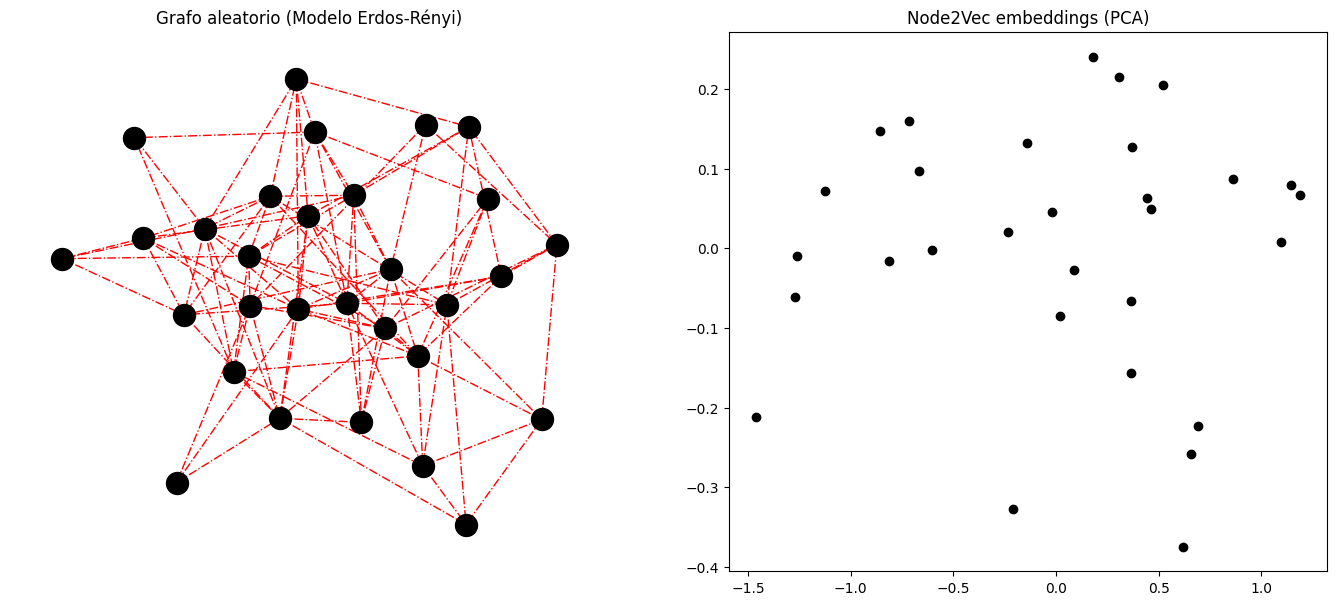

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.029098624363541603
Embeddings max: 0.9248237013816833
Embeddings min: -0.8516097068786621


In [102]:
visualization(g = "e_r")

**BARABASI-ALBERT**

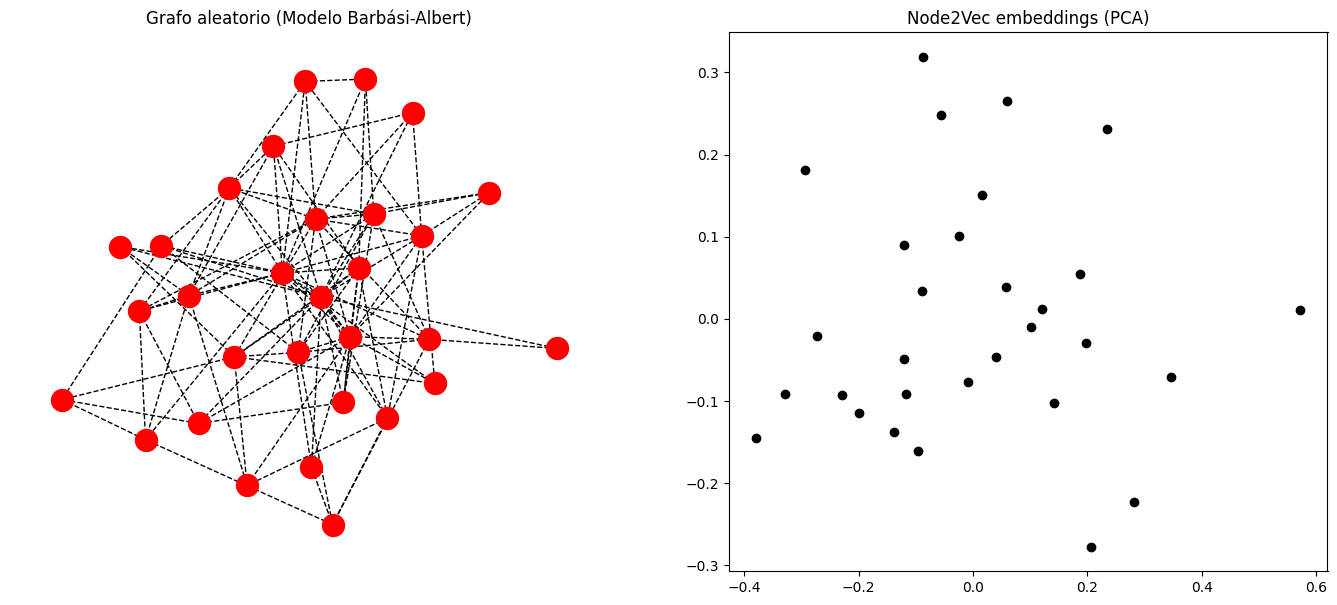

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.019641447812318802
Embeddings max: 0.7934609651565552
Embeddings min: -0.682494580745697


In [105]:
visualization("b_a")

**WATTS-STROGATZ**

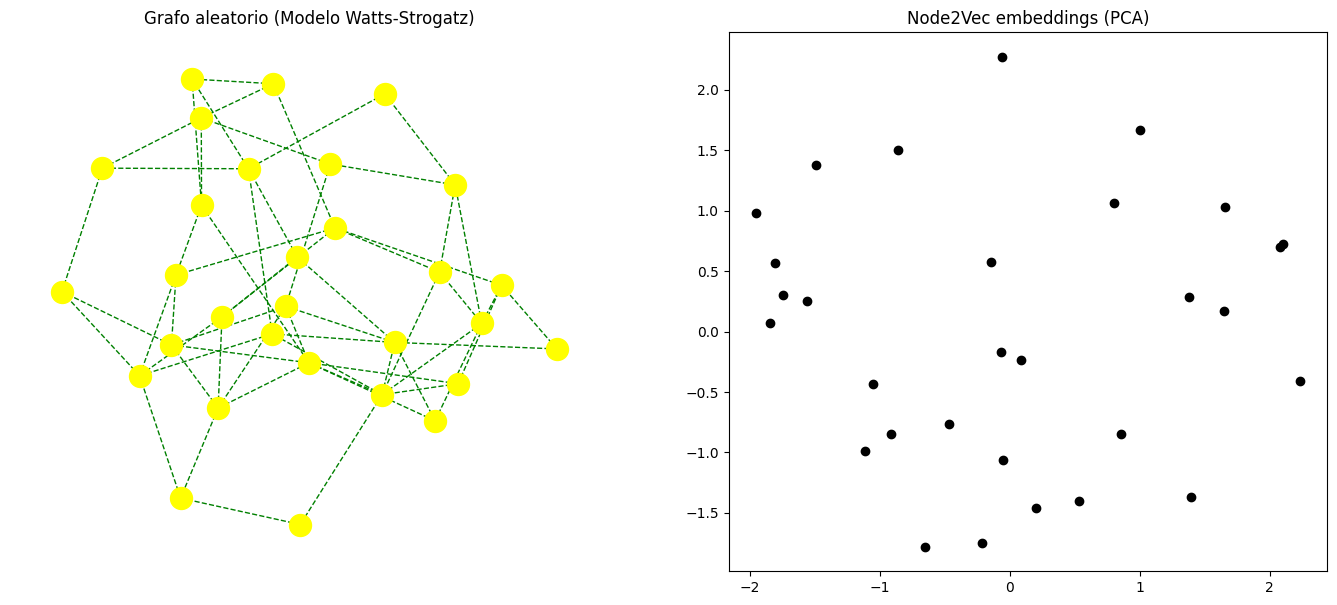

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.03376258164644241
Embeddings max: 1.4890154600143433
Embeddings min: -1.4824455976486206


In [107]:
visualization("w_s")

**RANDOM TREE**

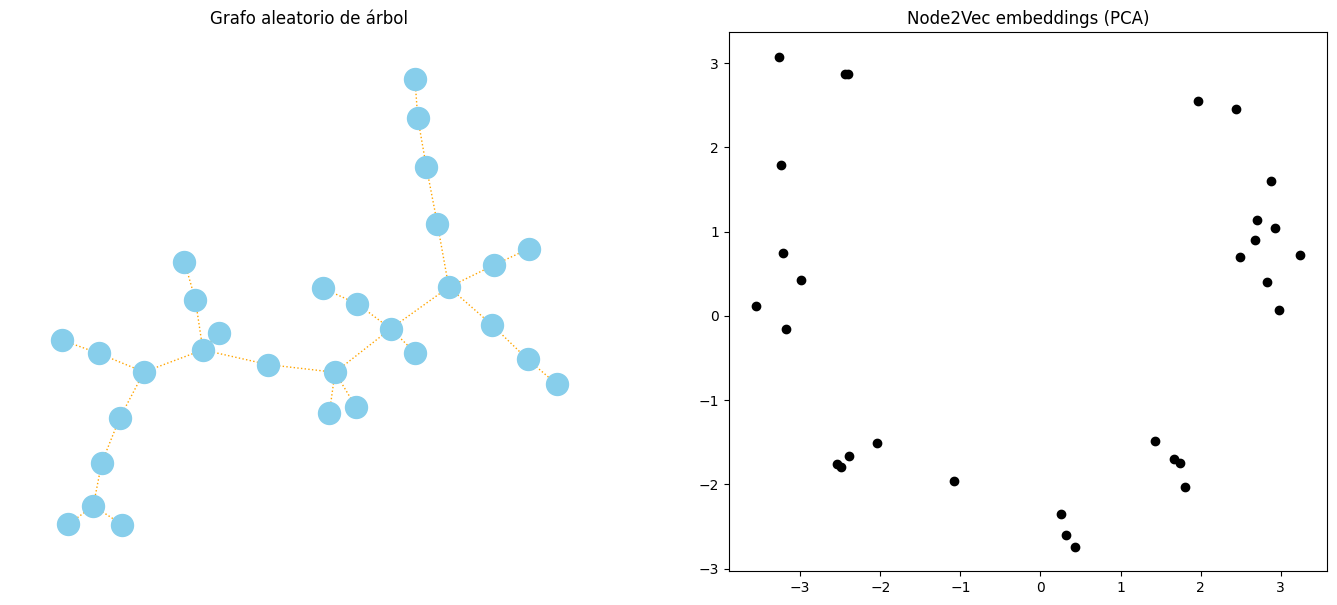

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.04506786912679672
Embeddings max: 2.1006007194519043
Embeddings min: -2.4348020553588867


In [116]:
visualization(g = "r_t")

**STOCHASTIC BLOCK MODEL**

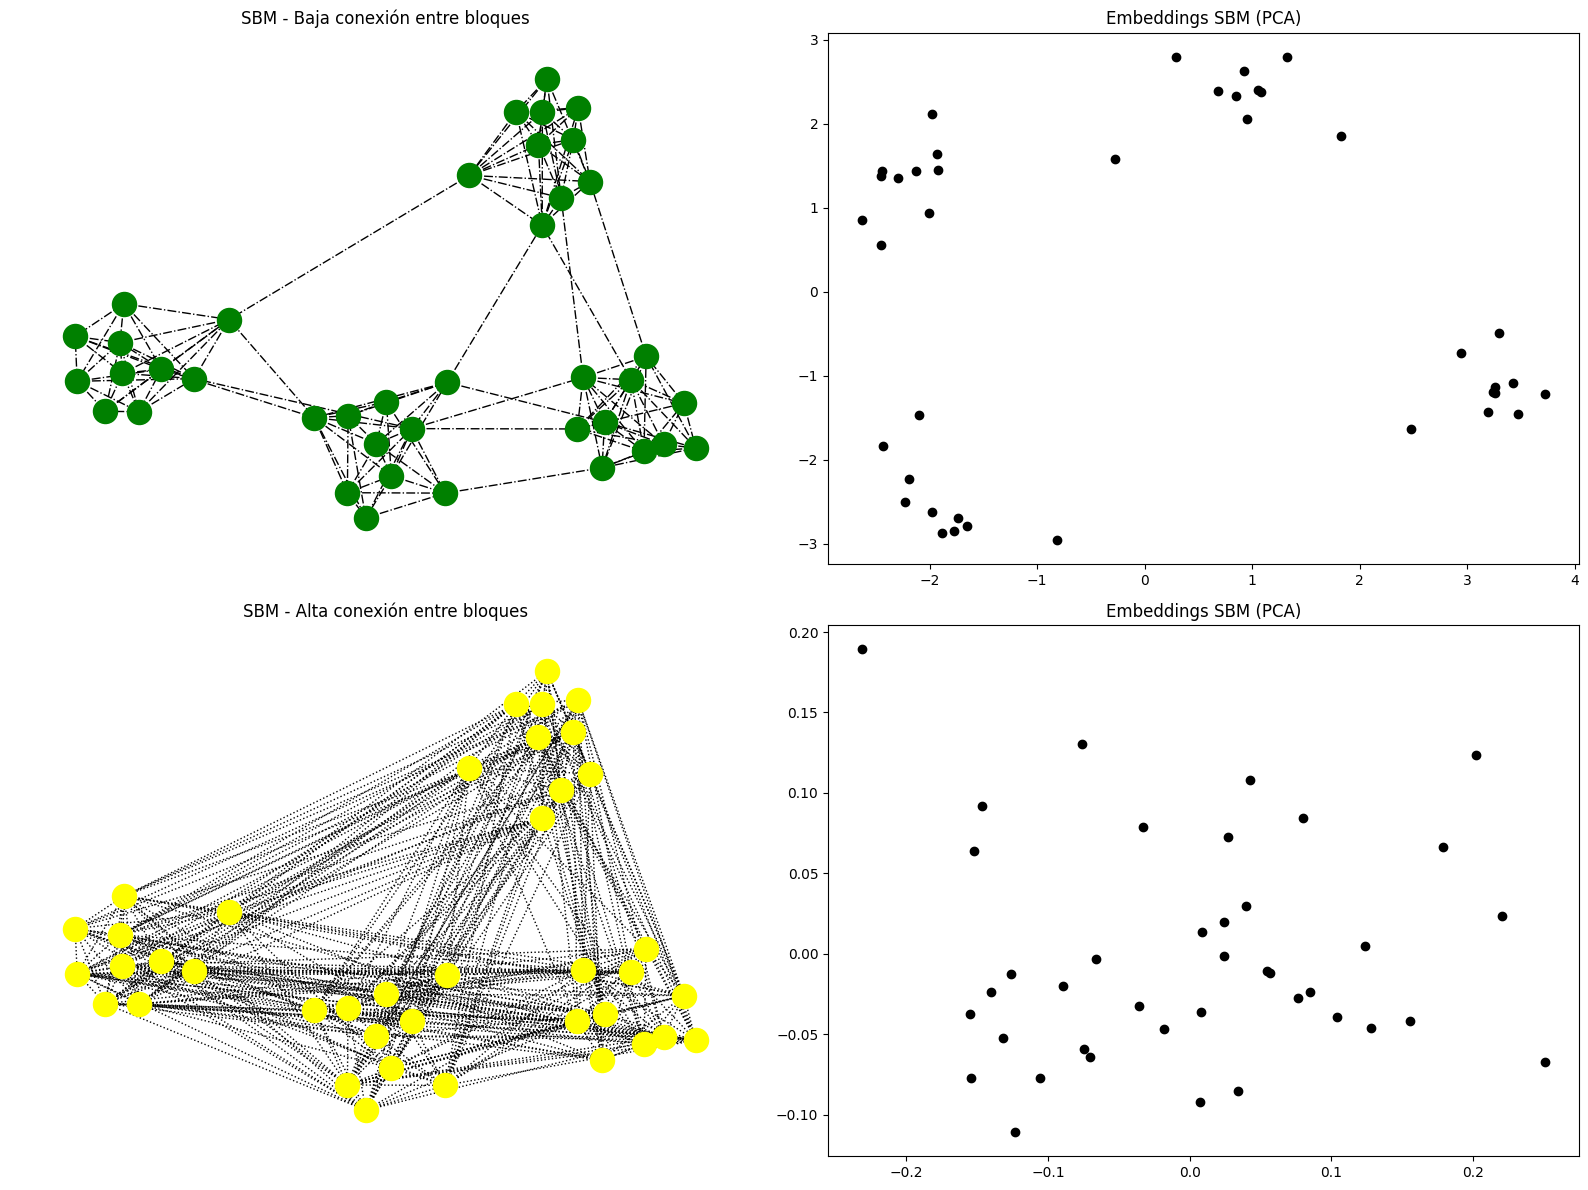

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: -0.012117553502321243
Embeddings max: 2.159261465072632
Embeddings min: -2.5241544246673584


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: 0.019504152238368988
Embeddings max: 0.6849344968795776
Embeddings min: -0.6467291712760925


In [122]:
visualization("SMB")

# Resultados y conslusiones

##### **¿Qué puedes decir sobre las incrustaciones de los nodos en el grafo?**
Los embeddings obtenidos representan cada nodo como un vector de 20 dimensiones que resume su papel (a nivel de estructura ...) dentro del grafo, el cual ha sido aprendido a partir de los random walks. Después de ver los resultados obtenidos, lo más a destacar es que  al observar los resultados de los 6 grafos, vemos como la forma de las embeddings reflejan las propiedades y caracterísiticas de cada modelo de grafos:

- En Erdos-Rényi y Barabási-Albert, las incrustaciones están distribuidas de forma desordenada, sin ningún patrón visible. Esto ocurre debido a que estos modelos de grafos no cuentan con ninguna estructura en comunidades ni nada por el estilo
- En Watts-Strogatz, la distribución es más extendida, reflejando la tensión entre clusterización local y los atajos del modelo de pequeño mundo.
- En el árbol, las incrustaciones muestran cierta separación en zonas. Esto captura la estructura jerárquica de ramas.
- En el SBM de baja conexión, las incrustaciones forman cuatro zonas claramente separadas, una por comunidad (caracterísitca clara del modelo SBM con baja conexión entre comunidades distintas)
- En el SBM de alta conexión, todas las incrustaciones colapsan en una nube compacta y casi indistinguible. Ocurre porque los bloques están tan interconectados que todos los nodos ven vecinos similares

En definitiva, podemos concluir que las incrustaciones no son arbitrarias puesto que se han visto reflejadas las caracterísitcas de los distintos modelos. Luego concluimos que los embeddings codifican la estructura real del grafo (si la estructura existe)

##### **¿Los nodos que están cerca en el grafo también están cerca en el espacio de incrustaciones?** 
Normalmente suele ser así, pero viene definido con matices según el tipo de grafo sobre el que estemos hablando:

- Erdos-Rényi: La proximidad en el grafo no se refleja bien en los embeddings. Al ser un grafo aleatorio sin estructura, los random walks mezclan todos los nodos por igual y no hay proximidad significativa que capturar

- Barabási-Albert: Ocurre parcialmente. Los nodos que comparten los mismos hubs (originales) tienden a aparecer en zonas similares, pero la nube sigue siendo difusa porque no hay comunidades definidas

- Watts-Strogatz: Parcialmente. La clusterización local se traduce en algo de agrupación, pero los atajos del modelo hacen que nodos que no son vecinos directos también aparezcan próximos en el embedding

- Árbol: En mayor medida que los anteriores. Al no haber ciclos, los random walks quedan "atrapados" en la misma subrama, por lo que nodos de la misma rama acaban con representaciones parecidas

- SBM baja conexión: Sí claramente. Es el caso donde esta propiedad se cumple mejor: los nodos de cada comunidad comparten casi todos sus vecinos y sus embeddings se agrupan visiblemente en cuatro zonas separadas

- SBM alta conexión: No. Con tanta conexión entre bloques, los random walks cruzan constantemente de una comunidad a otra y todos los nodos acaban con embeddings muy similares, independientemente de su posición en el grafo

##### **¿Qué puedes decir sobre la calidad de las incrustaciones?**

La calidad varía mucho entre grafos y es directamente proporcional a la claridad de la estructura del grafo:

- SBM baja conexión → calidad alta. Es el resultado más limpio: cuatro grupos perfectamente diferenciados en el scatter plot. Node2Vec ha identificado las comunidades sal 100%

- Árbol → calidad media-alta. La estructura jerárquica se captura bien, con zonas diferenciadas en el embedding, aunque no tan notables como en el SBM

- Watts-Strogatz → calidad media. Se captura algo de la estructura local, pero los atajos difuminan los grupos

- Barabási-Albert → calidad media-baja. Se aprecia algo más de varianza que en Erdos-Rényi, luego nos damos cuenta que node2vec recoge algo de la heterogeneidad de grados, pero sin separación clara

- Erdős-Rényi → calidad baja. Nube dispersa sin ningún patrón. Si el grafo no tiene estructura, Node2Vec no ha podido aprender mucho

- SBM alta conexión → calidad muy baja para detectar comunidades. Todos los embeddings colapsan en una nube compacta con valores mínimos (rango ±0.2), lo opuesto al SBM de baja conexión. Es el resultado más coherente con la teoría: cuando los bloques están muy interconectados, la estructura comunitaria desaparece desde el punto de vista de los random walks

##### **Y si pudieras mejorar la calidad de las incrustaciones, ¿cómo lo harías?**

Para mejorar la calidad de los embeddings de Node2Vec hay varios parámetros del algoritmo que podemos ajustar:

- **dimensions**: el tamaño del vector que representa cada nodo. Con valores más altos el modelo tiene más capacidad para capturar información, pero con grafos pequeños (como los nuestros de 30-40 nodos) tampoco hace falta aumentar mucho este valor (con 64 o 128 ya se nota mejora respecto a 20)

- **num_walks**: cuántos caminos aleatorios se generan por nodo. Cuantos más caminos, más "ejemplos" ve el modelo de cada nodo y mejor aprende su posición en el grafo. El coste es que tarda más en entrenar

- **walk_length**: la longitud de cada camino. Caminos más cortos capturan solo el vecindario inmediato (estructura local), caminos más largos permiten al modelo ver más lejos y capturar estructura global. Para grafos con comunidades bien definidas, caminos largos ayudan mucho

Para lograr una mejora en la calidad de los embeddings, vamos a cambiar los parámetros recién explicados y vamos a visualizar nuevamente los embeddings tanto con los parámetros por defecto como con los optimizados y comentar las posibles diferencias notables. Para lograr esto, vamos a modificar las funciones anteriores permitiendo pasar como parámetros dichos argumentos:

In [125]:
# FUNCIÓN NODE2VEC + EMBEDDINGS
def n2v(g, dimensions=20, num_walks=15, walk_length=90, reduction='pca'):
    """
    Función que aplica node2vec al grafo g y reduce los embeddings a 2D para poder visualizarlos.
    Los parámetros del algoritmo se pueden ajustar para mejorar la calidad de los embeddings:
        - dimensions : cuantos más, más información captura cada nodo (pero más lento)
        - num_walks  : cuantos más caminos, mejor aprende el modelo (pero más lento)
        - walk_length: caminos más largos capturan contexto más global del grafo
        - reduction  : 'pca' es más rápido, 'tsne' suele separar mejor los grupos

    Args
    -----
        - g          : Grafo sobre el que aplicar node2vec
        - dimensions : Dimensión de los embeddings (tamaño del vector de cada nodo)
        - num_walks  : Número de caminos aleatorios por nodo
        - walk_length: Longitud de cada camino aleatorio
        - reduction  : Técnica de reducción a usar ('pca' o 'tsne')

    Returns
    -------
        - embeddings_2d: Embeddings reducidos a 2 dimensiones
        - name         : Nombre de la técnica de reducción usada
        - embeddings   : Embeddings originales (alta dimensión)
    """
    model = node2vec(g, dimensions=dimensions, num_walks=num_walks, walk_length=walk_length)
    embeddings = np.array([model.wv[str(node)] for node in g.nodes()])  # embeddings

    # APLICAMOS REDUCCIÓN A LOS EMBEDDINGS OBTENIDOS
    if reduction == 'pca':
        embeddings_2d, name = pca(embeddings)
    else:
        embeddings_2d, name = t_sne(embeddings)

    return embeddings_2d, name, embeddings


# FUNCIÓN DE VISUALIZACIÓN
def visualization(g, dimensions=20, num_walks=15, walk_length=90, reduction='pca') -> None:  # Valores por defecto (como argumentos para posibles cambios)
    """
    Esta función muestra de forma visual un grafo y sus embeddings después de aplicar node2vec. El objetivo es mostrar en una figura 
    dos visualizaciones: en la primera mostramos el grafo original y en la segunda los embeddings del mismo. Además, debajo de imprimen
    por pantalla los datos obtenidos despues de aplicar node2vec al grafo. Para mostrar las visualizaciones, se utiliza o PCA o t-SNE,
    que se puede especificar con el parámetro reduction (por defecto PCA)

    Args
    -----
        - g          : Tipo de grafo sobre el que queremos aplicar el algoritmo node2vec
        - dimensions : Dimensión de los embeddings (tamaño del vector de cada nodo)
        - num_walks  : Número de caminos aleatorios por nodo
        - walk_length: Longitud de cada camino aleatorio
        - reduction  : Técnica de reducción a usar ('pca' o 'tsne')

    """

    # Construimos los casos según el tipo de grafo (ya que usamos los grafos creados en la práctica anterior)

    # ERDOS-RÉNYI
    if g == "e_r":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        e_r = nx.erdos_renyi_graph(30, 0.25, seed = 50)   # 30 nodos | Probabilidad de arista del 25%
        ax[0].set_title('Grafo aleatorio (Modelo Erdos-Rényi)')
        posiciones = nx.spring_layout(e_r, seed = 18)
        nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(e_r, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # BRABÁSI-ALBERT
    if g == "b_a":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        b_a = nx.barabasi_albert_graph(30, 4, seed = 50)   # 30 nodos | Nº enlaces por nodo: 4
        ax[0].set_title('Grafo aleatorio (Modelo Barbási-Albert)')
        posiciones = nx.spring_layout(b_a, seed = 18)
        nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(b_a, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # WATTS-STROGATZ
    if g == "w_s":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        w_s = nx.watts_strogatz_graph(30, 4, 0.5, seed = 50)   # 30 nodos | Grado medio: 4 | Probabilidad reconexión: 0.5
        ax[0].set_title('Grafo aleatorio (Modelo Watts-Strogatz)')
        posiciones = nx.spring_layout(w_s, seed = 18)
        nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(w_s, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # ÁRBOL
    if g == "r_t":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        r_t = nx.random_labeled_tree(30, seed = 50)   # 30 nodos 
        ax[0].set_title('Grafo aleatorio de árbol')
        posiciones = nx.spring_layout(r_t, seed = 18)
        nx.draw_networkx_nodes(r_t, posiciones, node_color = 'skyblue', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(r_t, posiciones, edge_color = 'orange', style = ':', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(r_t, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # SMB

    """
    Para este caso, vamos a realizar 4 subplots. En el lado izquierdo vamos a tener los dos grafos sintétcicos SBM,
    teniendo el grafo de baja conexión (entre comunidades) arriba y el grafo de alta conexión (entre comunidades) abajo.
    A la derecha tendremos los embeddings tanto como para SBM - baja conexión como con el SBM - alta conexión
    
    """
    if g == "SMB":
        sizes = [10, 10, 10, 10]
        baja = [[0.8, 0.02, 0.02, 0.02],[0.02, 0.8, 0.02, 0.02],[0.02, 0.02, 0.8, 0.02],[0.02, 0.02, 0.02, 0.8]]
        alta = [[0.8, 0.4, 0.4, 0.4],[0.4, 0.8, 0.4, 0.4],[0.4, 0.4, 0.8, 0.4],[0.4, 0.4, 0.4, 0.8]]
        seed = 96

        # Creamos grafos SBM
        G1 = nx.stochastic_block_model(sizes, baja, seed=seed)
        G2 = nx.stochastic_block_model(sizes, alta, seed=seed)

        # Aplicamos Node2Vec + reducción con los parámetros que nos pasen
        emb_baja, method_baja, embeddings_baja = n2v(G1, dimensions, num_walks, walk_length, reduction)
        emb_alta, method_alta, embeddings_alta = n2v(G2, dimensions, num_walks, walk_length, reduction)

        # Creamos figura 2x2
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Posiciones
        pos = nx.spring_layout(G1, seed=seed)

        # Baja conexión
        axes[0,0].set_title('SBM - Baja conexión entre bloques')
        nx.draw_networkx_nodes(G1, pos,node_size=300,node_color='green',ax=axes[0,0])
        nx.draw_networkx_edges(G1,pos,edge_color='black',style='-.',ax=axes[0,0])
        axes[0,0].axis('off')

        # Visualizamos embeddins
        axes[0,1].scatter(emb_baja[:,0],emb_baja[:,1],color='black')
        axes[0,1].set_title(f'Embeddings SBM ({method_baja})')

        # Alta conexion
        axes[1,0].set_title('SBM - Alta conexión entre bloques')

        nx.draw_networkx_nodes(G2,pos,node_size=300,node_color='yellow',ax=axes[1,0])
        nx.draw_networkx_edges(G2,pos,edge_color='black',style=':',ax=axes[1,0]
)
        # Visualizamos embeddins
        axes[1,0].axis('off')
        axes[1,1].scatter( emb_alta[:,0],emb_alta[:,1],color='black')
        axes[1,1].set_title(f'Embeddings SBM ({method_alta})')

        plt.show()

        display(Markdown('---'))
        properties(embeddings_baja)
        display(Markdown('---'))
        properties(embeddings_alta)

### Optimización

Ahora que hemos diseñado las funciones para ajustar los parámetros de `node2vec`, vamos a comparar la calidad de los embbeddings con los valores originiales y luego ajustando los parámetros (objetivo es mejorar calidad) para cada uno de los grafos sintéticos usados anteriormente (4 + 2)

Recordatorio de los valores originales:
```bash
- dimensions = 20
- num_walks = 15
- walk_lenght = 90
- reduction = 'pca'
```



##### **ERDOS-RÉNYI**

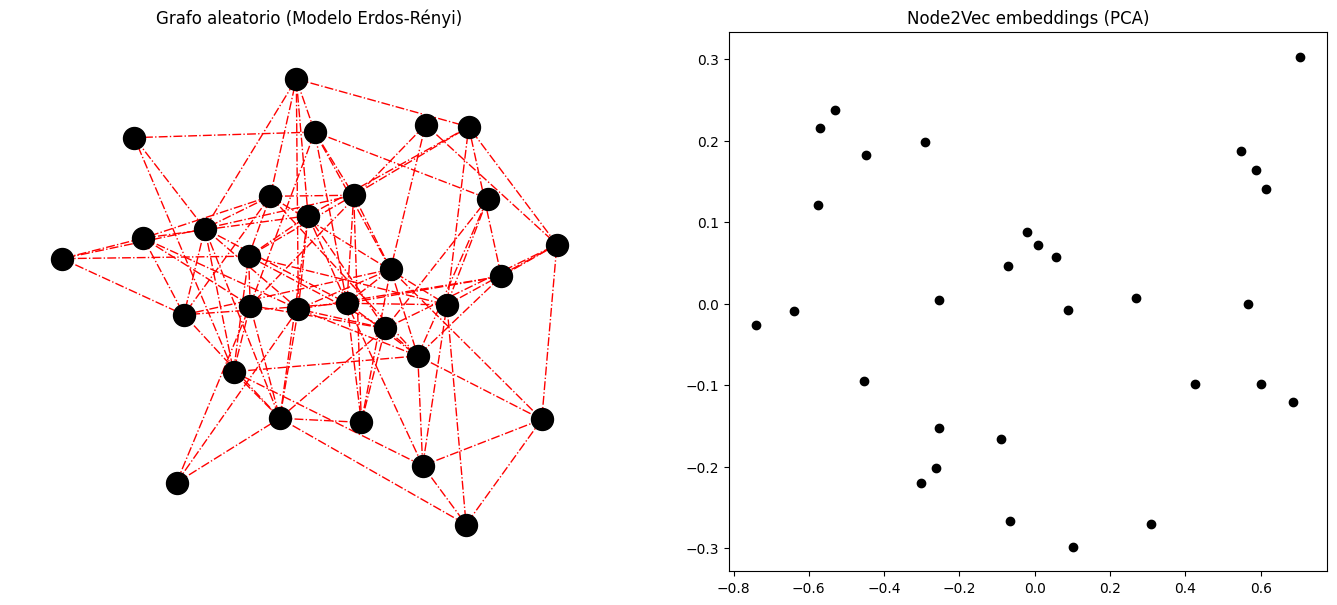

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.034052684903144836
Embeddings max: 0.8322095274925232
Embeddings min: -0.6061204075813293


---
**OPTIMIZACIÓN PARÁMETROS**
---

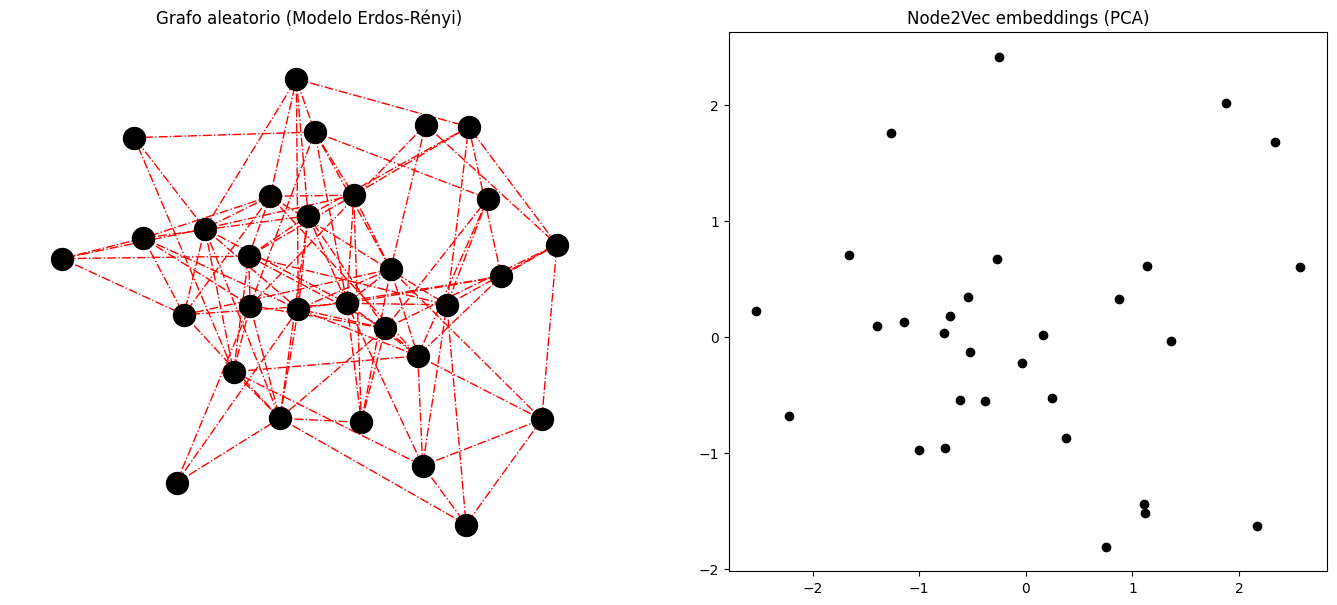

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.02915116585791111
Embeddings max: 1.7352396249771118
Embeddings min: -2.3273041248321533


In [ ]:
# ERDOS-RÉNYI
visualization("e_r")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# El grafo Erdos-Rényi no tiene estructura clara, así que subimos num_walks y walk_length
# para que el modelo vea más contexto de cada nodo y pueda capturar aunque sea las 
# pequeñas diferencias de conexiones que hay entre nodos

num_walks = 50
walk_lenght = 200

visualization("e_r", num_walks=num_walks, walk_length=walk_lenght)

Al aplicar Node2Vec al grafo de Erdős-Rényi con los parámetros base (num_walks=15, walk_length=90), los embeddings proyectados mediante PCA forman una nube dispersa sin ningún patrón visible, con valores comprendidos en un rango de aproximadamente +- 1.5. Tras incrementar el número de caminos a 50 y la longitud a 200, la distribución sigue siendo difusa pero se extiende ligeramente (+- 2.5), sin que aparezcan agrupaciones. Este resultado es coherente con la naturaleza del modelo puesto que al no existir estructura comunitaria ni roles diferenciados en el grafo, Node2Vec no tiene nada que aprender y el aumento de parámetros solo incrementa la varianza de los embeddings sin producir una separación notable

##### **BARABÁSI-ALBERT**

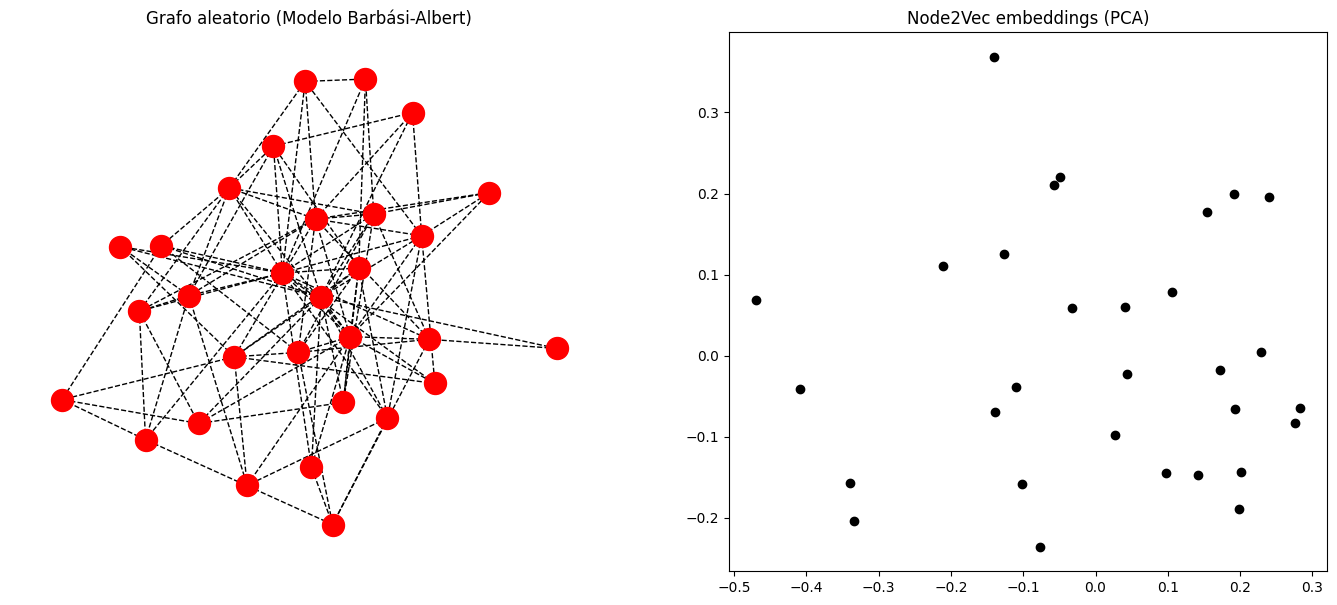

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.040437038987874985
Embeddings max: 0.7866019606590271
Embeddings min: -0.6641685366630554


---
**OPTIMIZACIÓN PARÁMETROS**
---

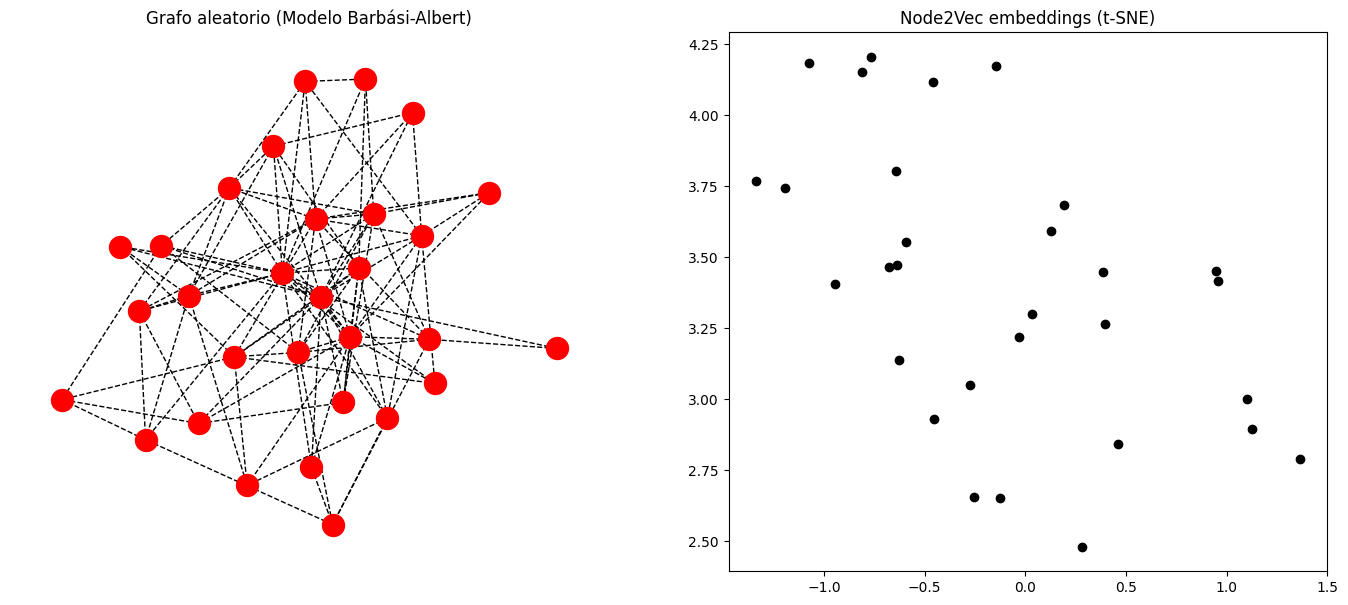

### **Información de los embeddings del grafo**

Embeddings shape: (30, 64)
Embeddings mean: 0.028317177668213844
Embeddings max: 0.56419438123703
Embeddings min: -0.4696846008300781


In [133]:
# BARABÁSI-ALBERT
visualization("b_a")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# En Barabási-Albert hay hubs muy conectados y nodos periféricos con pocas conexiones.
# Subimos dimensions para que el modelo tenga más capacidad de diferenciar estos roles,
# y usamos t-SNE porque separa mejor grupos con densidades tan distintas

dimensions = 64
reduction = 'tsne'

visualization("b_a", dimensions=dimensions, reduction=reduction)

En el grafo de Barabási-Albert, los embeddings base con PCA presentan una nube compacta y sin estructura aparente, con un rango de valores muy reducido (+-0.35). Al aumentar la dimensionalidad a 64 y visualizar con t-SNE, el scatter plot muestra una mayor dispersión de los puntos y una cierta separación emergente. Esta mejora se debe a dos factores combinados: por un lado, dimensiones más altas permiten al modelo capturar mejor la heterogeneidad de roles (nodos hub frente a nodos periféricos); por otro lado, t-SNE, al preservar las relaciones de vecindad local en lugar de buscar direcciones de máxima varianza global, es capaz de revelar agrupaciones sutiles que PCA aplana. Aun así, la separación no es tan nítida como en los grafos con comunidades bien definidas, lo que refleja que la estructura de Barabási-Albert es de naturaleza jerárquica y continua, no discreta

##### **WATTS-STROGATZ**

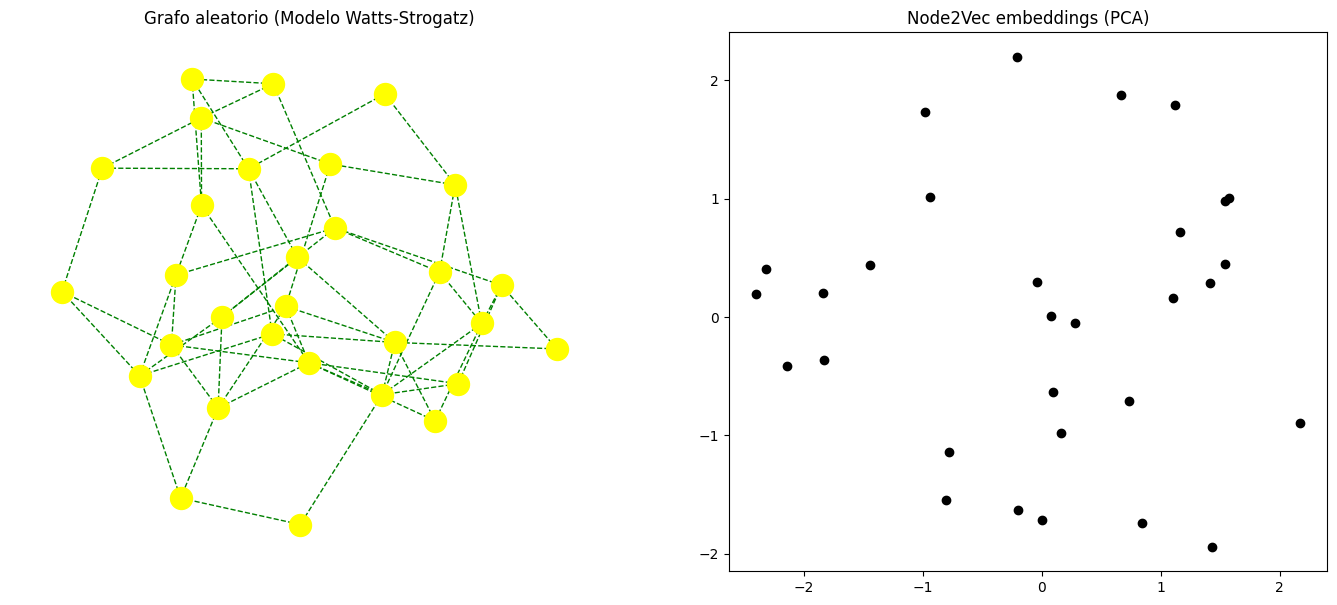

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.040033113211393356
Embeddings max: 1.710753321647644
Embeddings min: -1.5039844512939453


---
**OPTIMIZACIÓN PARÁMETROS**
---

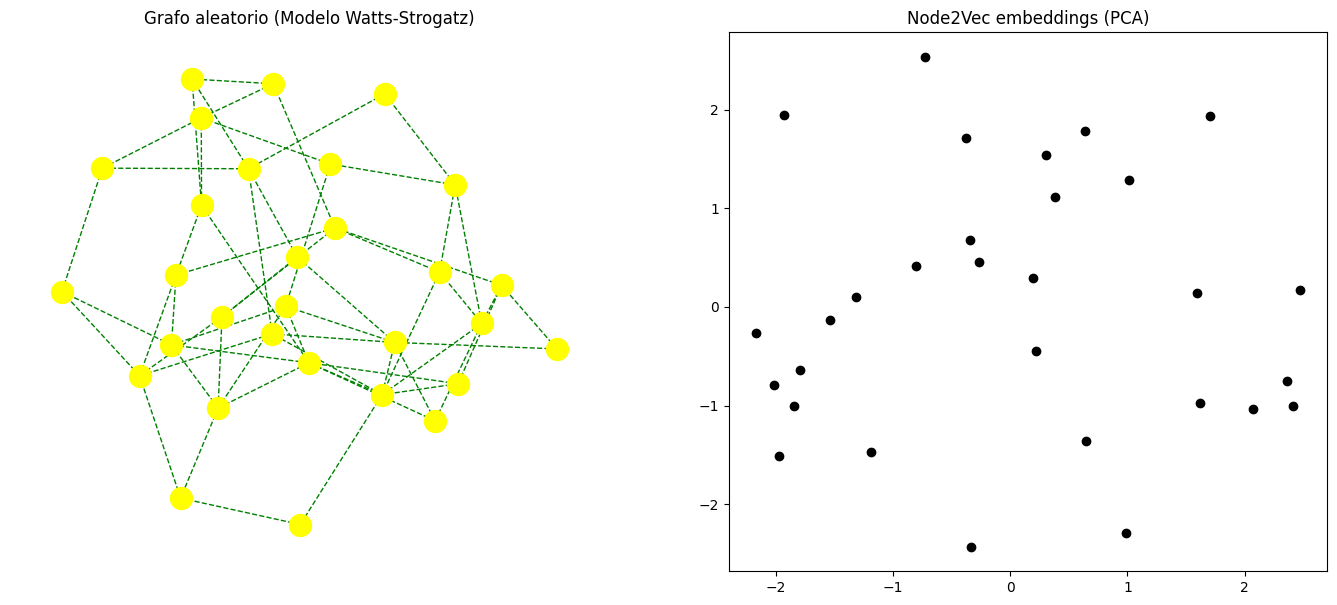

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.01734105683863163
Embeddings max: 1.8871383666992188
Embeddings min: -2.1637818813323975


In [135]:
# WATTS-STROGATZ
visualization("w_s")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# Watts-Strogatz tiene clusterización local pero con atajos que conectan nodos lejanos.
# Aumentamos walk_length para que los caminos puedan capturar tanto la estructura local
# como esos atajos, y así los embeddings reflejan mejor el balance entre ambas cosas

walk_length = 200

visualization("w_s", walk_length=walk_length)

El grafo de Watts-Strogatz, generado con probabilidad de reconexión p=0.5, produce embeddings base dispersos y sin agrupaciones visibles al visualizarlos con PCA. Al aumentar la longitud de los caminos a 200, la distribución se amplía ligeramente pero mantiene el mismo aspecto difuso. La escasa mejora se explica por la alta tasa de reconexión del modelo: con p=0.5 el grafo contiene numerosos atajos que rompen la clusterización local, haciendo que los random walks largos lleguen a cualquier zona del grafo con facilidad y no encuentren vecindarios diferenciados. Si la probabilidad de reconexión fuera baja (p =(+-)0.05), un mayor walk_length sería muy beneficioso para capturar la estructura anular original; pero con p=0.5 el grafo se asemeja demasiado a un aleatorio para que esta técnica aporte separación clara

##### **RANDOM TREE**

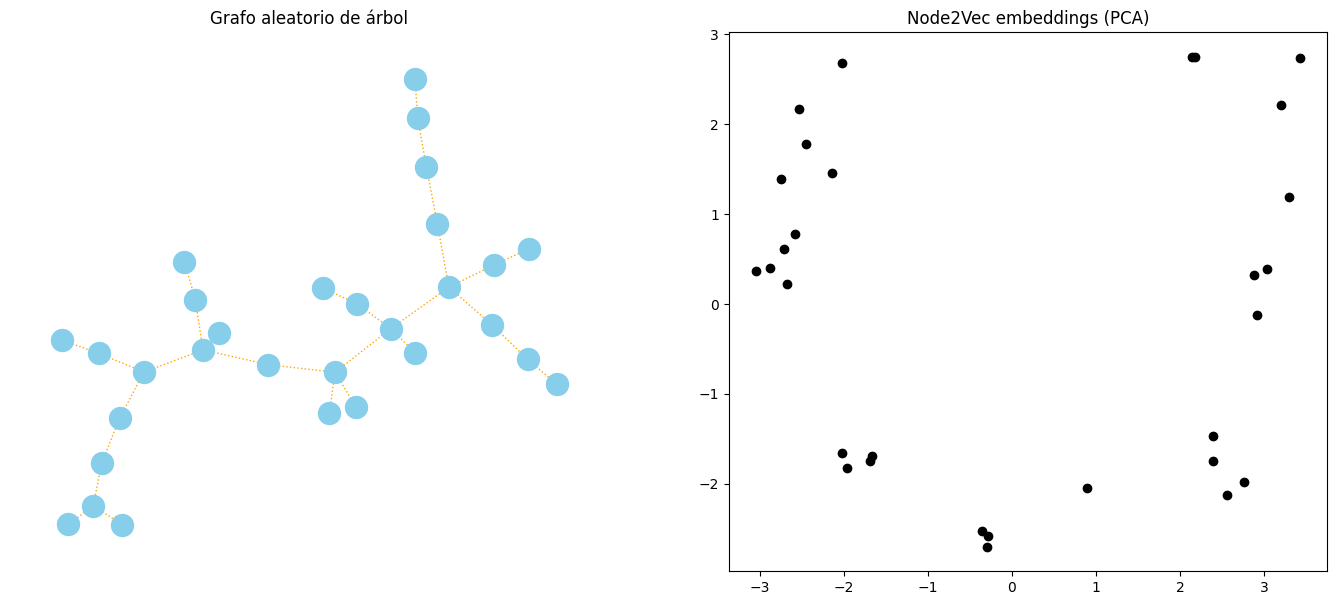

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.024168482050299644
Embeddings max: 2.5378687381744385
Embeddings min: -2.2976555824279785


---
**OPTIMIZACIÓN PARÁMETROS**
---

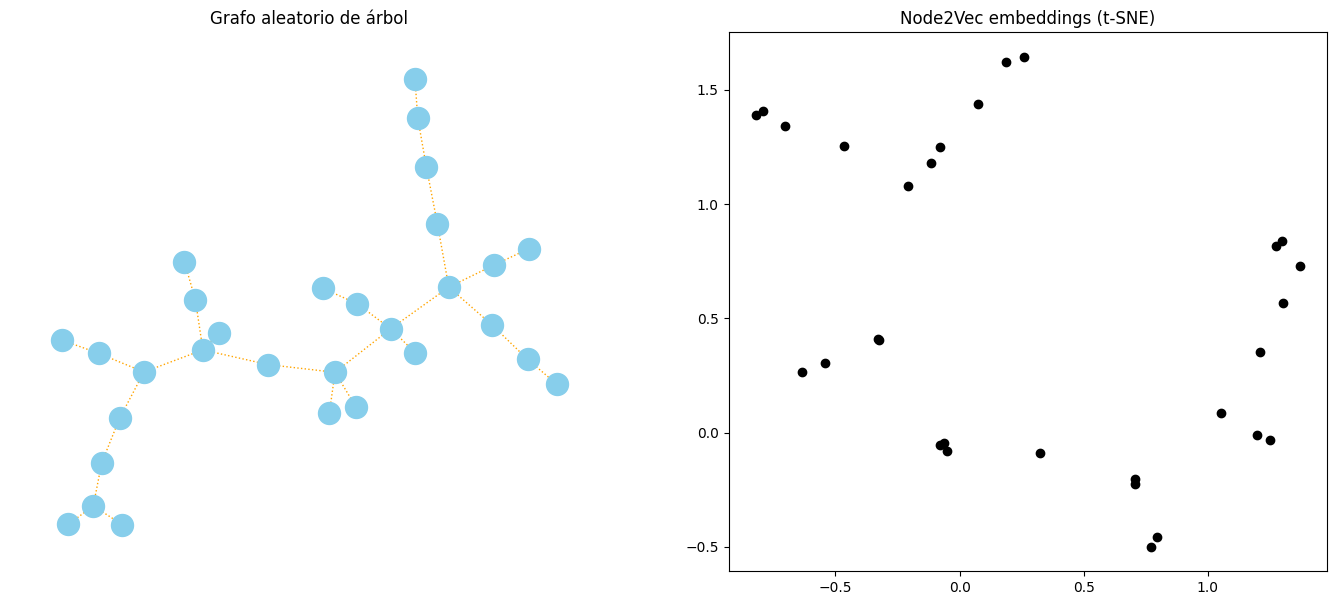

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: -0.017207063734531403
Embeddings max: 3.6479883193969727
Embeddings min: -4.442822456359863


In [134]:
# ÁRBOL
visualization("r_t")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# En un árbol no hay ciclos, así que los caminos aleatorios se quedan atrapados en ramas.
# Subimos num_walks para compensar esto (más caminos desde cada nodo = más variedad)
# y usamos t-SNE porque separa mejor la estructura jerárquica visualmente

num_walks = 50
reduction = 'tsne'

visualization("r_t", num_walks=num_walks, reduction=reduction)

En el árbol aleatorio, los embeddings base visualizados con PCA ya sugieren cierta separación en zonas (entre 3 y 4 regiones), aunque con bastante dispersión interna. Al incrementar el número de caminos a 50 y cambiar la visualización a t-SNE, los grupos se vuelven notablemente más compactos y diferenciados. La mejora se debe a que en un árbol la ausencia de ciclos confina los random walks a las ramas, por lo que más caminos equivale a mayor cobertura estadística y embeddings más estables por nodo. t-SNE contribuye adicionalmente porque, al preservar las relaciones de vecindad local, es capaz de resaltar la estructura jerárquica del árbol mejor que PCA, que solo captura la dirección de máxima varianza global y puede mezclar ramas que en el espacio original están bien separadas

##### **SMB**

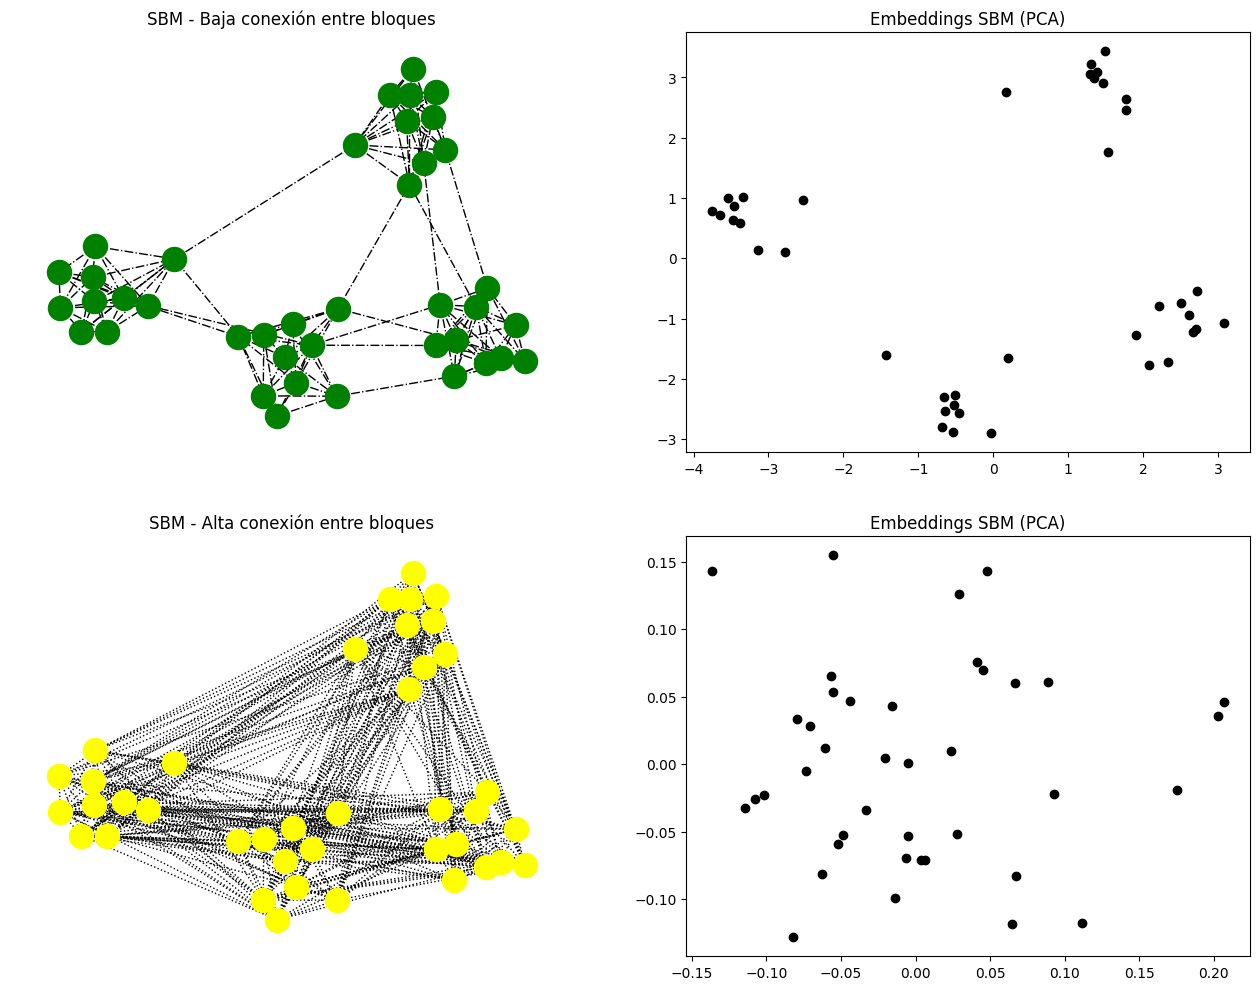

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: -0.0201939158141613
Embeddings max: 2.09932279586792
Embeddings min: -2.255525588989258


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: -0.02628866583108902
Embeddings max: 0.6208648681640625
Embeddings min: -0.6855122447013855


---
**OPTIMIZACIÓN PARÁMETROS**
---

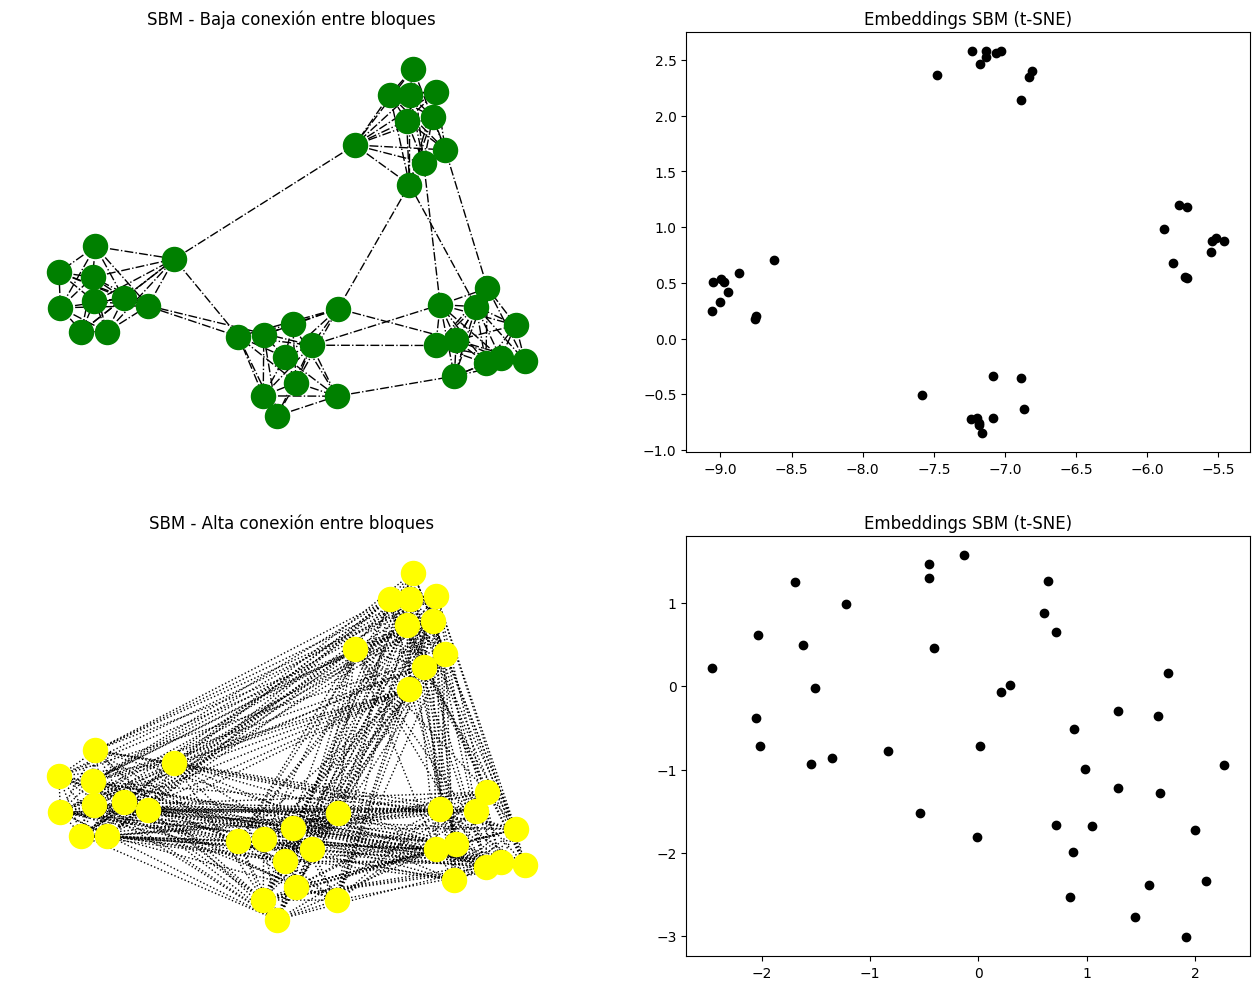

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 64)
Embeddings mean: 0.025028372183442116
Embeddings max: 1.500690221786499
Embeddings min: -1.5640051364898682


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 64)
Embeddings mean: 0.02943086065351963
Embeddings max: 0.43645137548446655
Embeddings min: -0.5075802803039551


In [136]:
# SBM
visualization("SMB")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# Para el SBM de baja conexión, con walk_length más largo y más dimensions le damos al 
# modelo más capacidad para separar aún mejor las 4 comunidades.
# Para el SBM de alta conexión el problema es la propia estructura del grafo (demasiada
# conexión entre bloques), así que la mejora de parámetros ayuda poco. Aun así usamos 
# t-SNE porque intenta separar mejor los puntos aunque estén muy juntos

dimensions = 64
walk_length = 200
reduction = 'tsne'

visualization("SMB", dimensions=dimensions, walk_length=walk_length, reduction=reduction)

**Baja conexión**: \
El SBM de baja conexión es el caso donde la optimización de parámetros produce el resultado más llamativo. Con los valores base y PCA ya se distinguían algunos agrupamientos, pero con 64 dimensiones, walk_length=200 y t-SNE los embeddings forman cuatro clústeres perfectamente delimitados, uno por comunidad. La explicación es que los tres cambios actúan de forma sinérgica sobre una estructura que ya existía: aumentar las dimensiones da al modelo más capacidad para codificar las diferencias entre bloques, caminos más largos profundizan la exploración dentro de cada comunidad al tiempo que los random walks rara vez cruzan al bloque vecino (probabilidad 0.02), y t-SNE es especialmente eficaz cuando los datos tienen agrupaciones discretas y bien separadas, que es exactamente el caso aquí. El resultado valida que Node2Vec es capaz de recuperar comunidades sin ningún tipo de etiqueta supervisada

**Alta conexión**: \
En el SBM de alta conexión, la optimización de parámetros no consigue revelar la estructura comunitaria porque dicha estructura ha desaparecido desde el punto de vista de los random walks. Con los valores base, los embeddings forman una nube muy compacta (rango +-0.2) que con t-SNE y 64 dimensiones se expande notablemente (rango hasta +- 3.6), pero sin mostrar ninguna agrupación discernible. La razón es que con una probabilidad de conexión entre bloques de 0.4, los random walks cruzan de comunidad en comunidad en prácticamente cada paso, haciendo que todos los nodos acumulen contextos similares independientemente de su bloque de origen. En estas condiciones, subir dimensiones, aumentar walk_length o usar t-SNE solo amplifica el ruido existente, no la señal, ya que la señal comunitaria es demasiado débil para que Node2Vec la capture. Es el resultado más instructivo de la práctica: los embeddings reflejan lo que hay en el grafo, y si el grafo no tiene estructura, los embeddings tampoco la tienen